# 10 — Transport models at every scale

How does each modeling stage behave as networks grow? This notebook walks the
scale ladder — from the 76-link Sioux Falls toy, through the bundled island and
regional models, to synthetic grids of up to 50,000 links generated on the fly —
and times every stage at every size. All data is embedded or generated
in-notebook; nothing is downloaded.

In [1]:
import time
import warnings
from pathlib import Path
from tempfile import gettempdir
from uuid import uuid4

import numpy as np
import pandas as pd

from aequilibrae.project import Project
from aequilibrae.utils.create_example import create_example
from aequilibrae.paths import TrafficAssignment, TrafficClass, NetworkSkimming
from aequilibrae.matrix import AequilibraeMatrix

warnings.filterwarnings("ignore")

rows = []
for name in ["sioux_falls", "nauru", "coquimbo"]:
    p = create_example(str(Path(gettempdir()) / uuid4().hex), name)
    with p.db_connection as conn:
        links, nodes = conn.execute(
            "select (select count(*) from links), (select count(*) from nodes)").fetchone()
        try:
            zones = conn.execute("select count(*) from zones").fetchone()[0]
        except Exception:
            zones = None
    rows.append({"model": name, "links": links, "nodes": nodes, "zones": zones})
    p.close()

pd.DataFrame(rows)

,model,links,nodes,zones
0,sioux_falls,76,24,24
1,nauru,1389,1239,0
2,coquimbo,19983,15724,133


## A synthetic network generator

Grid networks of any size, built through the standard editing API — every link
insert passes through the database consistency triggers that create nodes and
maintain `a_node`/`b_node`/`distance`, exactly as interactive editing does.

In [2]:
def build_grid_model(folder, n_links, n_centroids=25):
    """A square-grid model with n_links links and evenly spread centroids."""
    project = Project()
    project.new(folder)
    side = int(np.ceil((1 + np.sqrt(1 + 2 * n_links)) / 2))  # 2*s*(s-1) edges >= n_links
    lon0, lat0, step = 151.0, -33.0, 0.001

    with project.db_connection as conn:
        lt = conn.execute("select link_type from link_types limit 1").fetchone()[0]
        lid = 0
        for i in range(side):
            for j in range(side):
                x, y = lon0 + j * step, lat0 + i * step
                for x2, y2 in ((x + step, y), (x, y + step)):
                    if x2 >= lon0 + side * step or y2 >= lat0 + side * step or lid >= n_links:
                        continue
                    lid += 1
                    conn.execute(
                        "INSERT INTO links (link_id, a_node, b_node, link_type, modes, direction, "
                        "geometry) VALUES (?, 0, 0, ?, 'c', 0, GeomFromText(?, 4326))",
                        (lid, lt, f"LINESTRING({x} {y}, {x2} {y2})"))
        # free-flow attributes for assignment
        conn.execute("update links set speed_ab = 50, speed_ba = 50, "
                     "capacity_ab = 1000, capacity_ba = 1000, "
                     "travel_time_ab = distance / 1000.0 / 50 * 60, "
                     "travel_time_ba = distance / 1000.0 / 50 * 60")
        # evenly spread centroids
        node_ids = [r[0] for r in conn.execute("select node_id from nodes order by node_id")]
        stride = max(1, len(node_ids) // n_centroids)
        picks = node_ids[stride // 2::stride][:n_centroids]
        conn.executemany("update nodes set is_centroid = 1 where node_id = ?",
                         [(n,) for n in picks])
        conn.commit()
    return project

## Timing every stage at every scale

For each network size: build the network link-by-link, build the graph, skim all
centroid pairs, and run 10 iterations of BPR equilibrium assignment on a uniform
demand matrix.

In [3]:
def run_at_scale(n_links):
    folder = str(Path(gettempdir()) / uuid4().hex)
    t0 = time.perf_counter(); project = build_grid_model(folder, n_links)
    t_build = time.perf_counter() - t0

    t0 = time.perf_counter()
    project.network.build_graphs(modes=["c"])
    graph = project.network.graphs["c"]
    graph.set_graph("travel_time")
    graph.set_skimming(["travel_time"])
    graph.set_blocked_centroid_flows(False)
    t_graph = time.perf_counter() - t0

    t0 = time.perf_counter()
    NetworkSkimming(graph).execute()
    t_skim = time.perf_counter() - t0

    demand = AequilibraeMatrix()
    demand.create_empty(zones=graph.num_zones, matrix_names=["demand"], memory_only=True)
    demand.index = graph.centroids[:]
    demand.matrices[:, :, 0] = 5.0
    demand.computational_view()

    t0 = time.perf_counter()
    assig = TrafficAssignment()
    assig.add_class(TrafficClass(name="car", graph=graph, matrix=demand))
    assig.set_vdf("BPR"); assig.set_vdf_parameters({"alpha": 0.15, "beta": 4.0})
    assig.set_capacity_field("capacity"); assig.set_time_field("travel_time")
    assig.set_algorithm("msa"); assig.max_iter = 10; assig.rgap_target = 1e-10
    assig.execute()
    t_assign = time.perf_counter() - t0

    res = assig.results()
    row = {"links": n_links, "network_build_s": round(t_build, 2),
           "graph_s": round(t_graph, 2), "skim_s": round(t_skim, 2),
           "assignment_10it_s": round(t_assign, 2)}
    print(row, flush=True)
    return row, project, res


timings = []
for n in [1_000, 5_000, 20_000, 50_000]:
    row, project, res = run_at_scale(n)
    timings.append(row)
    if n < 50_000:
        project.close()

scaling = pd.DataFrame(timings).set_index("links")
scaling

[interactive offline map - run the notebook to display]

[interactive offline map - run the notebook to display]

[interactive offline map - run the notebook to display]

{'links': 1000, 'network_build_s': 2.22, 'graph_s': 0.08, 'skim_s': 0.09, 'assignment_10it_s': 0.32}


[interactive offline map - run the notebook to display]

...

[interactive offline map - run the notebook to display]

[interactive offline map - run the notebook to display]

[interactive offline map - run the notebook to display]

{'links': 50000, 'network_build_s': 38.59, 'graph_s': 0.99, 'skim_s': 0.09, 'assignment_10it_s': 0.38}


,network_build_s,graph_s,skim_s,assignment_10it_s
links,,,,
1000,2.22,0.08,0.09,0.32
5000,5.10,0.15,0.06,0.24
20000,16.58,0.40,0.05,0.29
50000,38.59,0.99,0.09,0.38


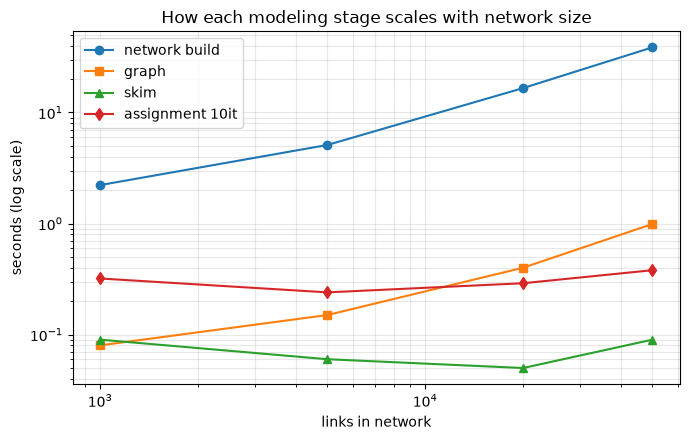

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
for col, marker in [("network_build_s", "o"), ("graph_s", "s"),
                    ("skim_s", "^"), ("assignment_10it_s", "d")]:
    ax.loglog(scaling.index, scaling[col].clip(lower=1e-3), marker=marker,
              label=col.replace("_s", "").replace("_", " "))
ax.set_xlabel("links in network")
ax.set_ylabel("seconds (log scale)")
ax.set_title("How each modeling stage scales with network size")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()

Every stage scales near-linearly with link count — including trigger-maintained
network building, whose per-link cost is flat from the first thousand links to the
fiftieth. On this ladder, a laptop covers everything from sketch models to a
metropolitan-scale network without leaving the notebook.

## Seeing a large model's results

The 50,000-link grid with its assigned flows, live on a offline map.

In [5]:
# Offline map helper ---------------------------------------------------------
# Interactive maps with no server extensions, no labextensions beyond the
# ipywidgets manager, and no CDN: lonboard renders WebGL maps whose frontend
# JavaScript ships from the kernel through the ipywidgets channel.
#
# Backends (AEQ_MAP_BACKEND environment variable):
#   lonboard (default) - interactive WebGL maps (pip install lonboard anywidget)
#   static             - matplotlib rendering, works absolutely anywhere
#
# The declarative symbology below (field()/constant() chains) is self-contained
# and renders identically on both backends.
import os

import matplotlib.colors
import matplotlib.pyplot as _plt
import numpy as np


# --- declarative symbology --------------------------------------------------
class _Mapping:
    def __init__(self, field, scheme, params):
        self.field, self.scheme, self.params = field, scheme, params

    def encoding(self, *targets):
        return {"field": self.field, "scheme": self.scheme,
                "params": self.params, "encodings": list(targets)}


class _Field:
    def __init__(self, name):
        self.name = name

    def colormap(self, name="viridis", *, domain=None, reverse=False, n_shades=9):
        return _Mapping(self.name, "colormap",
                        {"name": name, "domain": domain, "reverse": reverse})

    def scalar(self, *, domain, output_range):
        return _Mapping(self.name, "scalar",
                        {"domain": list(domain), "range": list(output_range)})

    def categorical(self, name="tab10"):
        return _Mapping(self.name, "categorical", {"name": name})


class _Constant:
    def __init__(self, value):
        self.value = value

    def encoding(self, *targets):
        scheme = "constant_num" if isinstance(self.value, (int, float)) else "constant_color"
        return {"field": None, "scheme": scheme,
                "params": {"value": self.value}, "encodings": list(targets)}


def field(name):
    """Style by a data column: .colormap() / .scalar() / .categorical()."""
    return _Field(name)


def constant(value):
    """A fixed colour (hex/name) or number, e.g. constant("#dc2626")."""
    return _Constant(value)


def _rgba255(c, alpha=1.0):
    r, g, b, a = matplotlib.colors.to_rgba(c, alpha)
    return [int(r * 255), int(g * 255), int(b * 255), int(a * 255)]


def _style_arrays(symbology, gdf):
    """symbology -> per-row uint8 RGBA arrays and float width arrays."""
    n = len(gdf)
    out = {"stroke": None, "width": None, "fill": None}
    if not symbology:
        return out
    mappings = [m for group in symbology for m in (group if isinstance(group, list) else [group])]
    for m in mappings:
        scheme, params, fld, encs = m["scheme"], m["params"], m["field"], m["encodings"]
        arr = wid = None
        if scheme == "constant_color":
            arr = np.tile(_rgba255(params["value"]), (n, 1)).astype(np.uint8)
        elif scheme == "colormap":
            cmap = _plt.get_cmap(params["name"])
            if params.get("reverse"):
                cmap = cmap.reversed()
            dom = params.get("domain") or [float(gdf[fld].min()), float(gdf[fld].max())]
            vals = gdf[fld].to_numpy(dtype=float)
            t = np.clip((vals - dom[0]) / max(dom[1] - dom[0], 1e-12), 0, 1)
            rgba = cmap(t)
            arr = (rgba * 255).astype(np.uint8)
        elif scheme == "categorical":
            cmap = _plt.get_cmap(params["name"])
            uniq = list(dict.fromkeys(gdf[fld].dropna()))
            idx = {v: i for i, v in enumerate(uniq)}
            arr = np.array([_rgba255(cmap(idx.get(v, 0) % cmap.N)) for v in gdf[fld]], dtype=np.uint8)
        elif scheme == "constant_num":
            wid = np.full(n, float(params["value"]))
        elif scheme == "scalar":
            d, r = params["domain"], params["range"]
            vals = gdf[fld].to_numpy(dtype=float)
            t = np.clip((vals - d[0]) / max(d[1] - d[0], 1e-12), 0, 1)
            wid = r[0] + t * (r[1] - r[0])
        if arr is not None:
            if any("stroke" in e for e in encs):
                out["stroke"] = arr
            if any("fill" in e for e in encs):
                out["fill"] = arr
        if wid is not None and any("width" in e for e in encs):
            out["width"] = wid
    return out


# --- the map document -------------------------------------------------------
class MapDoc:
    """Collects styled layers; displays via lonboard (WebGL) or matplotlib."""

    def __init__(self):
        self.items = []  # (gdf, name, arrays, opacity)

    def add(self, gdf, name, symbology, opacity):
        g = gdf.reset_index(drop=True).explode(index_parts=False).reset_index(drop=True)
        self.items.append((g, name, _style_arrays(symbology, g), opacity))

    def _lonboard_map(self):
        from lonboard import Map, PathLayer, PolygonLayer, ScatterplotLayer
        layers = []
        for g, name, st, op in self.items:
            if not len(g):
                continue
            geom = g.geometry.geom_type.iloc[0]
            base = g[["geometry"]]
            if "LineString" in geom:
                kw = {"width_units": "pixels", "width_min_pixels": 1.0, "opacity": op}
                if st["stroke"] is not None:
                    kw["get_color"] = st["stroke"]
                if st["width"] is not None:
                    kw["get_width"] = st["width"]
                layers.append(PathLayer.from_geopandas(base, **kw))
            elif "Polygon" in geom:
                kw = {"opacity": op * 0.6, "stroked": False}
                if st["fill"] is not None:
                    kw["get_fill_color"] = st["fill"]
                layers.append(PolygonLayer.from_geopandas(base, **kw))
            else:
                kw = {"radius_min_pixels": 5, "opacity": op}
                fill = st["fill"] if st["fill"] is not None else st["stroke"]
                if fill is not None:
                    kw["get_fill_color"] = fill
                layers.append(ScatterplotLayer.from_geopandas(base, **kw))
        return Map(layers=layers, basemap=None)

    def _static_figure(self):
        fig, ax = _plt.subplots(figsize=(9, 7))
        ax.set_facecolor("#eef1f4")
        for g, name, st, op in self.items:
            if not len(g):
                continue
            geom = g.geometry.geom_type.iloc[0]
            if "LineString" in geom:
                colors = st["stroke"] / 255 if st["stroke"] is not None else "#1d4ed8"
                widths = st["width"] if st["width"] is not None else 1.0
                g.plot(ax=ax, color=colors, linewidth=widths, alpha=op)
            elif "Polygon" in geom:
                colors = st["fill"] / 255 if st["fill"] is not None else "#cbd5e1"
                g.plot(ax=ax, color=colors, alpha=op * 0.6)
            else:
                fill = st["fill"] if st["fill"] is not None else st["stroke"]
                g.plot(ax=ax, color=(fill / 255 if fill is not None else "#dc2626"),
                       markersize=25, alpha=op)
        ax.set_aspect(1.4)
        ax.set_xticks([]), ax.set_yticks([])
        _plt.tight_layout()
        _plt.close(fig)
        return fig

    def _ipython_display_(self):
        from IPython.display import display
        be = os.environ.get("AEQ_MAP_BACKEND", "lonboard").strip().lower()
        display(self._static_figure() if be == "static" else self._lonboard_map())


def new_map(gdf_for_extent=None, zoom=12):
    """Create a map document (extent/zoom args kept for API compatibility;
    lonboard auto-fits to its layers)."""
    return MapDoc()


def add_gdf(doc, gdf, name, symbology=None, **kwargs):
    """Add a GeoDataFrame to the map as a styled layer."""
    doc.add(gdf, name, symbology, kwargs.get("opacity", 1.0))
    return name


def merge_lines(gdf, tol=0.01):
    """Collapse many lines into a single MultiLineString feature — backdrop
    layers do not need per-feature identity, and one merged feature is a
    fraction of the size and draw cost."""
    import geopandas as _gpd
    from shapely.geometry import MultiLineString
    parts = []
    for geom in gdf.geometry.simplify(tol):
        if geom is None or geom.is_empty:
            continue
        parts.extend(geom.geoms if geom.geom_type == "MultiLineString" else [geom])
    return _gpd.GeoDataFrame({"links": [len(parts)]}, geometry=[MultiLineString(parts)], crs=gdf.crs)


In [6]:
# field()/constant() symbology builders come from the map helper cell

flow_col = [c for c in res.columns if c.endswith("_tot")][0]
links_gdf = project.network.links.data
loaded = links_gdf.merge(res.reset_index(), on="link_id")
loaded = loaded[loaded[flow_col] > 0]

doc = new_map(links_gdf, zoom=13)
add_gdf(doc, loaded[["link_id", flow_col, "geometry"]], "assigned flows",
        symbology=[[field(flow_col).colormap("YlOrRd", domain=(0.0, float(loaded[flow_col].max()))).encoding("stroke"),
                field(flow_col).scalar(domain=(0.0, float(loaded[flow_col].max())),
                                       output_range=(0.8, 6.5)).encoding("stroke-width")]])
doc

[interactive offline map - run the notebook to display]

## Picking the right scale

| Scale | Links | Typical use | Feel |
|---|---|---|---|
| Toy (Sioux Falls) | ~10² | algorithm teaching, unit tests | instant |
| Small town / island (Nauru) | ~10²–10³ | sketch planning | instant |
| Regional city (Coquimbo) | ~10⁴ | full 4-step models (notebook 09) | seconds per stage |
| Metropolitan (synthetic 50k) | ~10⁴–10⁵ | corridor & network studies | seconds–minutes per stage |

Beyond this, the same workflow applies — assignment iterations dominate, so
converged equilibria on national-scale networks simply become batch jobs rather
than interactive sessions.